In [4]:
import os

import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
#from modisco.visualization import viz_sequence
import logomaker
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import deepdish
import pyBigWig
import tqdm
import sys
import pyfaidx
import pysam
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
#from utils.data_utils import load_test_data, get_seq
#from training.utils.data_utils import get_seq, get_seq_cts

import h5py
import hdf5plugin
import shap
import glob
tf.compat.v1.disable_eager_execution()

import scipy.stats
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import pyBigWig
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
#from plotnine import *
import anndata

ModuleNotFoundError: No module named 'pandas.core.index'

In [2]:
!pip install hdf5plugin
!conda install -c bioconda anndata -y

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 44.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Solving environment: unsuccessful initial attempt using frozen solve. Retrying with flexible solve.
Solving environment: unsuccessful attempt using repodata from current_repodata.json, retrying with next repodata source.
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.7.4
  latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.5.3



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - anndata


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    anndata-0.6.22.post

In [3]:
!pip install plotnine


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 96.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 25.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 37.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.0
    Uninstalling pandas-1.5.0:
      Successfully uninstalled pandas-1.5.0

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Zebrafish

In [5]:
# Shuffle sequence test plotting
shap_shuffled = '../../mouse_zebrafish/zebrafish/interpret/neural_da_peak_shuf.counts_scores.h5'
file = h5py.File(shap_shuffled,"r")
shap_scores_shuf = file['projected_shap']['seq'][:]

In [6]:
# Shuffle sequence test plotting
shap_original = '../../mouse_zebrafish/zebrafish/interpret/neural_da_peak_counts.counts_scores.h5'
file = h5py.File(shap_original,"r")
shap_scores_unshuf = file['projected_shap']['seq'][:]

In [7]:
shap_scores_shuf = shap_scores_shuf.transpose(0,2,1)
shap_scores_unshuf = shap_scores_unshuf.transpose(0,2,1)

In [8]:
shap_scores_shuf.shape

(8819, 2114, 4)

In [9]:
shap_scores_unshuf.shape

(8819, 2114, 4)

In [10]:
peak_motif = pd.read_csv('../../mouse_zebrafish/zebrafish/interpret/zebrafish_neural_peaks_motifhits_03172025.tsv', sep = '\t')

In [11]:
peak_motif

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,motif_rel_start,motif_rel_end
0,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),+,11.061537,4,NC_007112.7,650785,651325,310,315
1,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),-,11.061537,4,NC_007112.7,650785,651325,310,315
2,NC_007112.7,650921,650925,JC_0009|PBF(0.050),-,8.616696,4,NC_007112.7,650785,651325,136,140
3,NC_007112.7,651044,651052,JC_0025|MEIS1(var.2)(0.102),+,13.832114,4,NC_007112.7,650785,651325,259,267
4,NC_007112.7,651231,651241,JC_0039|Spz1(0.000),-,13.169168,4,NC_007112.7,650785,651325,446,456
...,...,...,...,...,...,...,...,...,...,...,...,...
426475,NC_007123.7,16354199,16354205,JC_0403|MXI1(0.153),-,12.540817,4187,NC_007123.7,16354142,16354379,57,63
426476,NC_007134.7,22845721,22845727,JC_0298|ARF8(0.140),-,11.902166,8031,NC_007134.7,22845512,22845834,209,215
426477,NC_007134.7,22845532,22845536,JC_0303|PHYPADRAFT_140773(0.030),+,7.501382,8031,NC_007134.7,22845512,22845834,20,24
426478,NC_007134.7,22845722,22845729,JC_0304|DREB2C(0.094),-,14.171743,8031,NC_007134.7,22845512,22845834,210,217


In [12]:
all_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/neural_da_peak_counts.interpreted_regions.bed",sep="\t",header=None)
all_peaks.columns = ['peak_chrom','peak_start','peak_end','Peak_index','score','strand','X','Y','Z','summit']
all_peaks = all_peaks[['peak_chrom','peak_start','peak_end','summit']]


In [13]:
peak_motif_merged = pd.merge(peak_motif,all_peaks,how = "left",on=["peak_chrom","peak_start","peak_end"])
peak_motif_merged['motif_rel_start_new'] = peak_motif_merged['motif_rel_start']-peak_motif_merged['summit']+1057
peak_motif_merged['motif_rel_end_new'] = peak_motif_merged['motif_rel_end']-peak_motif_merged['summit']+1057

In [14]:
peak_motif_merged

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,motif_rel_start,motif_rel_end,summit,motif_rel_start_new,motif_rel_end_new
0,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),+,11.061537,4,NC_007112.7,650785,651325,310,315,326,1041,1046
1,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),-,11.061537,4,NC_007112.7,650785,651325,310,315,326,1041,1046
2,NC_007112.7,650921,650925,JC_0009|PBF(0.050),-,8.616696,4,NC_007112.7,650785,651325,136,140,326,867,871
3,NC_007112.7,651044,651052,JC_0025|MEIS1(var.2)(0.102),+,13.832114,4,NC_007112.7,650785,651325,259,267,326,990,998
4,NC_007112.7,651231,651241,JC_0039|Spz1(0.000),-,13.169168,4,NC_007112.7,650785,651325,446,456,326,1177,1187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426475,NC_007123.7,16354199,16354205,JC_0403|MXI1(0.153),-,12.540817,4187,NC_007123.7,16354142,16354379,57,63,126,988,994
426476,NC_007134.7,22845721,22845727,JC_0298|ARF8(0.140),-,11.902166,8031,NC_007134.7,22845512,22845834,209,215,192,1074,1080
426477,NC_007134.7,22845532,22845536,JC_0303|PHYPADRAFT_140773(0.030),+,7.501382,8031,NC_007134.7,22845512,22845834,20,24,192,885,889
426478,NC_007134.7,22845722,22845729,JC_0304|DREB2C(0.094),-,14.171743,8031,NC_007134.7,22845512,22845834,210,217,192,1075,1082


In [15]:
# Here is where I do all the calculation needed 

sum_motif = np.empty(len(peak_motif))
mean_motif = np.empty(len(peak_motif))
sum_null = np.empty(len(peak_motif))
mean_null = np.empty(len(peak_motif))
sum_motif_norm = np.empty(len(peak_motif))
mean_motif_norm = np.empty(len(peak_motif))
sum_null_norm = np.empty(len(peak_motif))
mean_null_norm = np.empty(len(peak_motif))

for peak_index, group in peak_motif_merged.groupby("peak_index"):
    # Iterate over grouped table by peak
    score_track_null = (shap_scores_shuf[peak_index])
    score_track_obs = (shap_scores_unshuf[peak_index])
    
    for i, row in group.iterrows():
        shap_null = score_track_null[row["motif_rel_start_new"]:row["motif_rel_end_new"]]
        shap_obs = score_track_obs[row["motif_rel_start_new"]:row["motif_rel_end_new"]]
        sum_null[i] = np.sum(shap_null)
        mean_null[i] = np.mean(shap_null)
        sum_motif[i] = np.sum(shap_obs)
        mean_motif[i] = np.mean(shap_obs)
        sum_null_norm[i] = sum_null[i]/np.mean(score_track_null)
        mean_null_norm[i] = mean_null[i]/np.mean(score_track_null)
        sum_motif_norm[i] = sum_motif[i]/np.mean(score_track_obs)
        mean_motif_norm[i] = mean_motif[i]/np.mean(score_track_obs)
    
peak_motif_merged["motif_sum"] = sum_motif 
peak_motif_merged["motif_mean"] = mean_motif
peak_motif_merged["null_sum"] = sum_null 
peak_motif_merged["null_mean"] = mean_null

peak_motif_merged["motif_sum_norm"] = sum_motif_norm 
peak_motif_merged["motif_mean_norm"] = mean_motif_norm
peak_motif_merged["null_sum_norm"] = sum_null_norm 
peak_motif_merged["null_mean_norm"] = mean_null_norm


/opt/conda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.9/site-packages/numpy/core/_methods.py:127: RuntimeWarning: invalid value encountered in divide
  ret = arr.dtype.type(ret / rcount)
/tmp/ipykernel_6323/2650560203.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  sum_null_norm[i] = sum_null[i]/np.mean(score_track_null)
/tmp/ipykernel_6323/2650560203.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  mean_null_norm[i] = mean_null[i]/np.mean(score_track_null)


In [16]:
peak_motif_merged

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,...,motif_rel_start_new,motif_rel_end_new,motif_sum,motif_mean,null_sum,null_mean,motif_sum_norm,motif_mean_norm,null_sum_norm,null_mean_norm
0,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),+,11.061537,4,NC_007112.7,650785,651325,...,1041,1046,-0.009712,-0.000486,-0.001006,-0.000050,-42.411244,-2.120770,-20.813810,-1.040691
1,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),-,11.061537,4,NC_007112.7,650785,651325,...,1041,1046,-0.009712,-0.000486,-0.001006,-0.000050,-42.411244,-2.120770,-20.813810,-1.040691
2,NC_007112.7,650921,650925,JC_0009|PBF(0.050),-,8.616696,4,NC_007112.7,650785,651325,...,867,871,-0.009834,-0.000615,0.005745,0.000359,-42.944300,-2.684019,118.845869,7.427867
3,NC_007112.7,651044,651052,JC_0025|MEIS1(var.2)(0.102),+,13.832114,4,NC_007112.7,650785,651325,...,990,998,-0.007805,-0.000244,-0.014740,-0.000461,-34.082249,-1.065070,-304.927250,-9.528977
4,NC_007112.7,651231,651241,JC_0039|Spz1(0.000),-,13.169168,4,NC_007112.7,650785,651325,...,1177,1187,0.185669,0.004642,0.160889,0.004025,810.777720,20.272775,3328.315660,83.255240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426475,NC_007123.7,16354199,16354205,JC_0403|MXI1(0.153),-,12.540817,4187,NC_007123.7,16354142,16354379,...,988,994,0.011795,0.000492,0.003235,0.000135,29.964870,1.248940,-290.224599,-12.085561
426476,NC_007134.7,22845721,22845727,JC_0298|ARF8(0.140),-,11.902166,8031,NC_007134.7,22845512,22845834,...,1074,1080,0.059814,0.002491,0.020416,0.000851,156.702061,6.525921,-12233.142857,-509.714286
426477,NC_007134.7,22845532,22845536,JC_0303|PHYPADRAFT_140773(0.030),+,7.501382,8031,NC_007134.7,22845512,22845834,...,885,889,0.007309,0.000457,-0.003870,-0.000242,19.148032,1.196752,2318.857143,144.928571
426478,NC_007134.7,22845722,22845729,JC_0304|DREB2C(0.094),-,14.171743,8031,NC_007134.7,22845512,22845834,...,1075,1082,0.066833,0.002388,0.001415,0.000051,175.090568,6.256090,-848.000000,-30.285714


In [17]:
peak_motif_merged.to_csv('../../mouse_zebrafish/zebrafish/interpret/zebrafish_neural_da_SHAP.tsv',sep="\t",index = None)

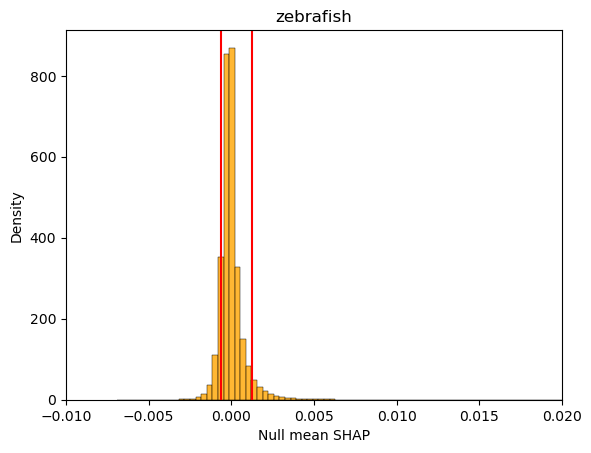

In [33]:
sns.histplot(peak_motif_merged['null_mean'], bins=100, stat='density', color='#ffa500', alpha=0.8)
for q in null_quantiles:
    plt.axvline(x=q, color='red')

plt.title('zebrafish')
plt.xlabel('Null mean SHAP')
plt.xlim(-0.01, 0.02)
plt.show()

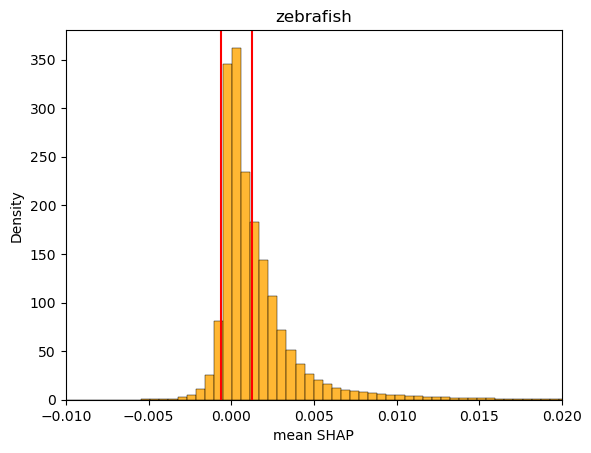

In [34]:
import seaborn as sns
sns.histplot(peak_motif_merged['motif_mean'], bins=100, stat='density', color='#ffa500', alpha=0.8)
for q in null_quantiles:
    plt.axvline(x=q, color='red')

plt.title('zebrafish')
plt.xlabel('mean SHAP')
plt.xlim(-0.01, 0.02)
plt.show()

In [37]:
peak_motif_merged

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,...,motif_rel_start_new,motif_rel_end_new,motif_sum,motif_mean,null_sum,null_mean,motif_sum_norm,motif_mean_norm,null_sum_norm,null_mean_norm
0,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),+,11.061537,4,NC_007112.7,650785,651325,...,1041,1046,-0.009712,-0.000486,-0.001006,-0.000050,-42.411244,-2.120770,-20.813810,-1.040691
1,NC_007112.7,651095,651100,JC_0000|BIM2(0.105),-,11.061537,4,NC_007112.7,650785,651325,...,1041,1046,-0.009712,-0.000486,-0.001006,-0.000050,-42.411244,-2.120770,-20.813810,-1.040691
2,NC_007112.7,650921,650925,JC_0009|PBF(0.050),-,8.616696,4,NC_007112.7,650785,651325,...,867,871,-0.009834,-0.000615,0.005745,0.000359,-42.944300,-2.684019,118.845869,7.427867
3,NC_007112.7,651044,651052,JC_0025|MEIS1(var.2)(0.102),+,13.832114,4,NC_007112.7,650785,651325,...,990,998,-0.007805,-0.000244,-0.014740,-0.000461,-34.082249,-1.065070,-304.927250,-9.528977
4,NC_007112.7,651231,651241,JC_0039|Spz1(0.000),-,13.169168,4,NC_007112.7,650785,651325,...,1177,1187,0.185669,0.004642,0.160889,0.004025,810.777720,20.272775,3328.315660,83.255240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426475,NC_007123.7,16354199,16354205,JC_0403|MXI1(0.153),-,12.540817,4187,NC_007123.7,16354142,16354379,...,988,994,0.011795,0.000492,0.003235,0.000135,29.964870,1.248940,-290.224599,-12.085561
426476,NC_007134.7,22845721,22845727,JC_0298|ARF8(0.140),-,11.902166,8031,NC_007134.7,22845512,22845834,...,1074,1080,0.059814,0.002491,0.020416,0.000851,156.702061,6.525921,-12233.142857,-509.714286
426477,NC_007134.7,22845532,22845536,JC_0303|PHYPADRAFT_140773(0.030),+,7.501382,8031,NC_007134.7,22845512,22845834,...,885,889,0.007309,0.000457,-0.003870,-0.000242,19.148032,1.196752,2318.857143,144.928571
426478,NC_007134.7,22845722,22845729,JC_0304|DREB2C(0.094),-,14.171743,8031,NC_007134.7,22845512,22845834,...,1075,1082,0.066833,0.002388,0.001415,0.000051,175.090568,6.256090,-848.000000,-30.285714


In [46]:
# Now, let's put threshold and see what we recover 
active_thresh = 0.97

print('Active Threshold:', active_thresh)



active_motifs = peak_motif_merged.loc[(peak_motif_merged['motif_mean'] >= np.nanquantile(peak_motif_merged['null_mean'], active_thresh))].reset_index(drop=True).copy() #| 
#                                #(peak_motif['motif_mean'] <= np.quantile(null_bp_scores, 1 - active_thresh))].reset_index(drop=True).copy()

print(np.quantile(peak_motif_merged['null_mean'], active_thresh))
#print(np.quantile(null_bp_scores, 1 - active_thresh))

display(active_motifs.head(20))
display(active_motifs.shape)

Active Threshold: 0.97
nan


,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,...,motif_rel_start_new,motif_rel_end_new,motif_sum,motif_mean,null_sum,null_mean,motif_sum_norm,motif_mean_norm,null_sum_norm,null_mean_norm
0,NC_007112.7,651231,651241,JC_0039|Spz1(0.000),-,13.169168,4,NC_007112.7,650785,651325,...,1177,1187,0.185669,0.004642,0.160889,0.004025,810.777720,20.272775,3328.315660,83.255240
1,NC_007112.7,651138,651151,JC_0040|PPARD(0.070),+,17.466475,4,NC_007112.7,650785,651325,...,1084,1097,0.457520,0.008797,0.014053,0.000270,1997.892764,38.413326,290.722565,5.588163
2,NC_007112.7,651185,651191,JC_0095|AFT2(0.045),-,11.800947,4,NC_007112.7,650785,651325,...,1131,1137,0.081604,0.003399,-0.008530,-0.000355,356.347736,14.842270,-176.453761,-7.348952
3,NC_007112.7,651222,651229,JC_0124|IME1(0.000),-,14.173243,4,NC_007112.7,650785,651325,...,1168,1175,0.165527,0.005909,0.097412,0.003479,722.823529,25.803227,2015.171393,71.970407
4,NC_007112.7,651234,651247,JC_0280|RFX2(0.147),+,17.900072,4,NC_007112.7,650785,651325,...,1180,1193,0.243164,0.004677,0.123047,0.002367,1061.846955,20.422697,2545.479655,48.966708
5,NC_007112.7,651234,651247,JC_0280|RFX2(0.147),-,17.383924,4,NC_007112.7,650785,651325,...,1180,1193,0.243164,0.004677,0.123047,0.002367,1061.846955,20.422697,2545.479655,48.966708
6,NC_007112.7,5695037,5695042,JC_0000|BIM2(0.105),+,11.061537,19,NC_007112.7,5694803,5695630,...,1141,1146,0.455078,0.022751,-0.005875,-0.000294,963.521454,48.169611,-684.444444,-34.222222
7,NC_007112.7,5695037,5695042,JC_0000|BIM2(0.105),-,11.061537,19,NC_007112.7,5694803,5695630,...,1141,1146,0.455078,0.022751,-0.005875,-0.000294,963.521454,48.169611,-684.444444,-34.222222
8,NC_007112.7,5694976,5694982,JC_0001|Pax2(0.321),-,10.844980,19,NC_007112.7,5694803,5695630,...,1080,1086,0.132812,0.005535,-0.010368,-0.000432,281.199394,11.719334,-1208.000000,-50.333333
9,NC_007112.7,5695010,5695028,JC_0028|RREB1(0.047),+,15.829717,19,NC_007112.7,5694803,5695630,...,1114,1132,0.411621,0.005718,-0.013649,-0.000190,871.511358,12.107017,-1590.222222,-22.083333


(130289, 23)

In [49]:
active_motifs.to_csv('../../mouse_zebrafish/zebrafish/interpret/zebrafish_neural_da_SHAP_filtered_97.tsv',sep="\t",index = None)

## Mouse

In [51]:
# Shuffle sequence test plotting
shap_shuffled = '../../mouse_zebrafish/mouse/interpret/neural_da_peak_shuf.counts_scores.h5'
file = h5py.File(shap_shuffled,"r")
shap_scores_shuf = file['projected_shap']['seq'][:]

In [53]:
# Shuffle sequence test plotting
shap_original = '../../mouse_zebrafish/mouse/interpret/mouse_da_peaks.counts_scores.h5'
file = h5py.File(shap_original,"r")
shap_scores_unshuf = file['projected_shap']['seq'][:]

In [54]:
shap_scores_shuf = shap_scores_shuf.transpose(0,2,1)
shap_scores_unshuf = shap_scores_unshuf.transpose(0,2,1)

In [55]:
shap_scores_shuf.shape

(12047, 2114, 4)

In [56]:
shap_scores_unshuf.shape

(12047, 2114, 4)

In [57]:
peak_motif = pd.read_csv('../../mouse_zebrafish/mouse/interpret/mouse_neural_peaks_motifhits_03172025.tsv', sep = '\t')

In [58]:
peak_motif

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,motif_rel_start,motif_rel_end
0,chr1,12577319,12577324,JC_0000|BIM2(0.105),+,11.364814,362,chr1,12576820,12577420,499,504
1,chr1,12577319,12577324,JC_0000|BIM2(0.105),-,11.364814,362,chr1,12576820,12577420,499,504
2,chr1,12576921,12576925,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,101,105
3,chr1,12577065,12577069,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,245,249
4,chr1,12576918,12576923,JC_0019|ZNF384(0.534),+,10.683245,362,chr1,12576820,12577420,98,103
...,...,...,...,...,...,...,...,...,...,...,...,...
457085,chr10,94943977,94943982,JC_0306|GATA15(0.173),+,9.655418,4391,chr10,94943942,94944542,35,40
457086,chr10,94943977,94943982,JC_0306|GATA15(0.173),-,9.655418,4391,chr10,94943942,94944542,35,40
457087,chr10,94944319,94944324,JC_0316|MYB(0.055),-,11.455574,4391,chr10,94943942,94944542,377,382
457088,chr10,94944038,94944048,JC_0336|AT3G57600(0.106),-,14.865927,4391,chr10,94943942,94944542,96,106


In [60]:
all_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/mouse_da_peaks.interpreted_regions.bed",sep="\t",header=None)
all_peaks.columns = ['peak_chrom','peak_start','peak_end','Peak_index','score','strand','X','Y','Z','summit']
all_peaks = all_peaks[['peak_chrom','peak_start','peak_end','summit']]


In [61]:
peak_motif_merged = pd.merge(peak_motif,all_peaks,how = "left",on=["peak_chrom","peak_start","peak_end"])
peak_motif_merged['motif_rel_start_new'] = peak_motif_merged['motif_rel_start']-peak_motif_merged['summit']+1057
peak_motif_merged['motif_rel_end_new'] = peak_motif_merged['motif_rel_end']-peak_motif_merged['summit']+1057

In [62]:
peak_motif_merged

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,motif_rel_start,motif_rel_end,summit,motif_rel_start_new,motif_rel_end_new
0,chr1,12577319,12577324,JC_0000|BIM2(0.105),+,11.364814,362,chr1,12576820,12577420,499,504,300,1256,1261
1,chr1,12577319,12577324,JC_0000|BIM2(0.105),-,11.364814,362,chr1,12576820,12577420,499,504,300,1256,1261
2,chr1,12576921,12576925,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,101,105,300,858,862
3,chr1,12577065,12577069,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,245,249,300,1002,1006
4,chr1,12576918,12576923,JC_0019|ZNF384(0.534),+,10.683245,362,chr1,12576820,12577420,98,103,300,855,860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457085,chr10,94943977,94943982,JC_0306|GATA15(0.173),+,9.655418,4391,chr10,94943942,94944542,35,40,300,792,797
457086,chr10,94943977,94943982,JC_0306|GATA15(0.173),-,9.655418,4391,chr10,94943942,94944542,35,40,300,792,797
457087,chr10,94944319,94944324,JC_0316|MYB(0.055),-,11.455574,4391,chr10,94943942,94944542,377,382,300,1134,1139
457088,chr10,94944038,94944048,JC_0336|AT3G57600(0.106),-,14.865927,4391,chr10,94943942,94944542,96,106,300,853,863


In [63]:
# Here is where I do all the calculation needed 

sum_motif = np.empty(len(peak_motif))
mean_motif = np.empty(len(peak_motif))
sum_null = np.empty(len(peak_motif))
mean_null = np.empty(len(peak_motif))
sum_motif_norm = np.empty(len(peak_motif))
mean_motif_norm = np.empty(len(peak_motif))
sum_null_norm = np.empty(len(peak_motif))
mean_null_norm = np.empty(len(peak_motif))

for peak_index, group in peak_motif_merged.groupby("peak_index"):
    # Iterate over grouped table by peak
    score_track_null = (shap_scores_shuf[peak_index])
    score_track_obs = (shap_scores_unshuf[peak_index])
    
    for i, row in group.iterrows():
        shap_null = score_track_null[row["motif_rel_start_new"]:row["motif_rel_end_new"]]
        shap_obs = score_track_obs[row["motif_rel_start_new"]:row["motif_rel_end_new"]]
        sum_null[i] = np.sum(shap_null)
        mean_null[i] = np.mean(shap_null)
        sum_motif[i] = np.sum(shap_obs)
        mean_motif[i] = np.mean(shap_obs)
        sum_null_norm[i] = sum_null[i]/np.mean(score_track_null)
        mean_null_norm[i] = mean_null[i]/np.mean(score_track_null)
        sum_motif_norm[i] = sum_motif[i]/np.mean(score_track_obs)
        mean_motif_norm[i] = mean_motif[i]/np.mean(score_track_obs)
    
peak_motif_merged["motif_sum"] = sum_motif 
peak_motif_merged["motif_mean"] = mean_motif
peak_motif_merged["null_sum"] = sum_null 
peak_motif_merged["null_mean"] = mean_null

peak_motif_merged["motif_sum_norm"] = sum_motif_norm 
peak_motif_merged["motif_mean_norm"] = mean_motif_norm
peak_motif_merged["null_sum_norm"] = sum_null_norm 
peak_motif_merged["null_mean_norm"] = mean_null_norm


/tmp/ipykernel_6323/2650560203.py:24: RuntimeWarning: divide by zero encountered in scalar divide
/tmp/ipykernel_6323/2650560203.py:25: RuntimeWarning: divide by zero encountered in scalar divide


In [70]:
peak_motif_merged

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,...,motif_rel_start_new,motif_rel_end_new,motif_sum,motif_mean,null_sum,null_mean,motif_sum_norm,motif_mean_norm,null_sum_norm,null_mean_norm
0,chr1,12577319,12577324,JC_0000|BIM2(0.105),+,11.364814,362,chr1,12576820,12577420,...,1256,1261,0.016037,0.000802,0.023773,0.001189,46.293187,2.315210,-505.510773,-25.287706
1,chr1,12577319,12577324,JC_0000|BIM2(0.105),-,11.364814,362,chr1,12576820,12577420,...,1256,1261,0.016037,0.000802,0.023773,0.001189,46.293187,2.315210,-505.510773,-25.287706
2,chr1,12576921,12576925,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,...,858,862,0.007710,0.000482,0.003008,0.000188,22.254646,1.390915,-63.959442,-3.997465
3,chr1,12577065,12577069,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,...,1002,1006,0.028046,0.001753,-0.028503,-0.001781,80.958018,5.059876,606.093790,37.880862
4,chr1,12576918,12576923,JC_0019|ZNF384(0.534),+,10.683245,362,chr1,12576820,12577420,...,855,860,0.002733,0.000137,0.001858,0.000093,7.889883,0.394357,-39.503169,-1.974651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457085,chr10,94943977,94943982,JC_0306|GATA15(0.173),+,9.655418,4391,chr10,94943942,94944542,...,792,797,-0.000441,-0.000022,-0.007301,-0.000365,20.903955,1.045198,343.126050,17.165266
457086,chr10,94943977,94943982,JC_0306|GATA15(0.173),-,9.655418,4391,chr10,94943942,94944542,...,792,797,-0.000441,-0.000022,-0.007301,-0.000365,20.903955,1.045198,343.126050,17.165266
457087,chr10,94944319,94944324,JC_0316|MYB(0.055),-,11.455574,4391,chr10,94943942,94944542,...,1134,1139,-0.001534,-0.000077,0.004784,0.000239,72.677966,3.632768,-224.806723,-11.238095
457088,chr10,94944038,94944048,JC_0336|AT3G57600(0.106),-,14.865927,4391,chr10,94943942,94944542,...,853,863,0.001199,0.000030,-0.001392,-0.000035,-56.813559,-1.420904,65.434174,1.635854


In [71]:
peak_motif_merged.to_csv('../../mouse_zebrafish/mouse/interpret/mouse_neural_da_SHAP.tsv',sep="\t",index = None)

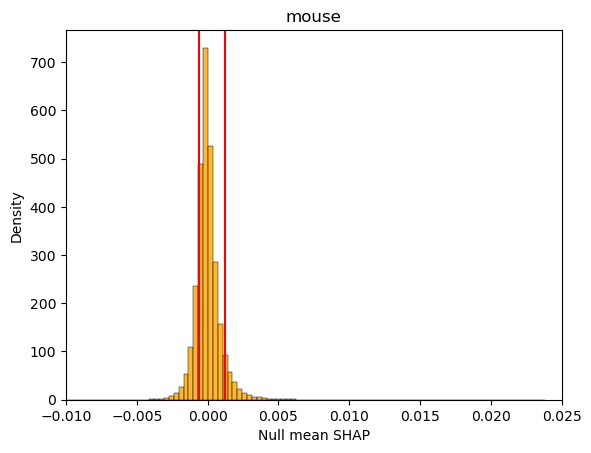

In [80]:
sns.histplot(peak_motif_merged['null_mean'], bins=100, stat='density', color='#ffa500', alpha=0.8)
for q in null_quantiles:
    plt.axvline(x=q, color='red')

plt.title('mouse')
plt.xlabel('Null mean SHAP')
plt.xlim(-0.01, 0.025)
plt.show()

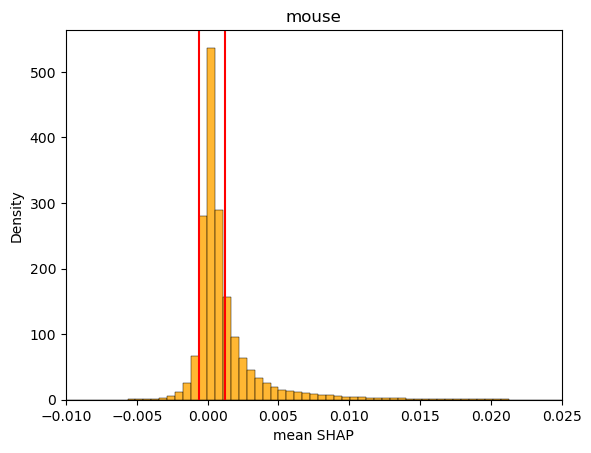

In [79]:
import seaborn as sns
sns.histplot(peak_motif_merged['motif_mean'], bins=100, stat='density', color='#ffa500', alpha=0.8)
for q in null_quantiles:
    plt.axvline(x=q, color='red')

plt.title('mouse')
plt.xlabel('mean SHAP')
plt.xlim(-0.01, 0.025)
plt.show()

In [74]:
peak_motif_merged

,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,...,motif_rel_start_new,motif_rel_end_new,motif_sum,motif_mean,null_sum,null_mean,motif_sum_norm,motif_mean_norm,null_sum_norm,null_mean_norm
0,chr1,12577319,12577324,JC_0000|BIM2(0.105),+,11.364814,362,chr1,12576820,12577420,...,1256,1261,0.016037,0.000802,0.023773,0.001189,46.293187,2.315210,-505.510773,-25.287706
1,chr1,12577319,12577324,JC_0000|BIM2(0.105),-,11.364814,362,chr1,12576820,12577420,...,1256,1261,0.016037,0.000802,0.023773,0.001189,46.293187,2.315210,-505.510773,-25.287706
2,chr1,12576921,12576925,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,...,858,862,0.007710,0.000482,0.003008,0.000188,22.254646,1.390915,-63.959442,-3.997465
3,chr1,12577065,12577069,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,...,1002,1006,0.028046,0.001753,-0.028503,-0.001781,80.958018,5.059876,606.093790,37.880862
4,chr1,12576918,12576923,JC_0019|ZNF384(0.534),+,10.683245,362,chr1,12576820,12577420,...,855,860,0.002733,0.000137,0.001858,0.000093,7.889883,0.394357,-39.503169,-1.974651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457085,chr10,94943977,94943982,JC_0306|GATA15(0.173),+,9.655418,4391,chr10,94943942,94944542,...,792,797,-0.000441,-0.000022,-0.007301,-0.000365,20.903955,1.045198,343.126050,17.165266
457086,chr10,94943977,94943982,JC_0306|GATA15(0.173),-,9.655418,4391,chr10,94943942,94944542,...,792,797,-0.000441,-0.000022,-0.007301,-0.000365,20.903955,1.045198,343.126050,17.165266
457087,chr10,94944319,94944324,JC_0316|MYB(0.055),-,11.455574,4391,chr10,94943942,94944542,...,1134,1139,-0.001534,-0.000077,0.004784,0.000239,72.677966,3.632768,-224.806723,-11.238095
457088,chr10,94944038,94944048,JC_0336|AT3G57600(0.106),-,14.865927,4391,chr10,94943942,94944542,...,853,863,0.001199,0.000030,-0.001392,-0.000035,-56.813559,-1.420904,65.434174,1.635854


In [77]:
# Now, let's put threshold and see what we recover 
active_thresh = 0.95

print('Active Threshold:', active_thresh)



active_motifs = peak_motif_merged.loc[(peak_motif_merged['motif_mean'] >= np.nanquantile(peak_motif_merged['null_mean'], active_thresh))].reset_index(drop=True).copy() #| 
#                                #(peak_motif['motif_mean'] <= np.quantile(null_bp_scores, 1 - active_thresh))].reset_index(drop=True).copy()

print(np.quantile(peak_motif_merged['null_mean'], active_thresh))
#print(np.quantile(null_bp_scores, 1 - active_thresh))

display(active_motifs.head(20))
display(active_motifs.shape)

Active Threshold: 0.95
0.001506805419921875


,chrom,start,end,key,strand,score,peak_index,peak_chrom,peak_start,peak_end,...,motif_rel_start_new,motif_rel_end_new,motif_sum,motif_mean,null_sum,null_mean,motif_sum_norm,motif_mean_norm,null_sum_norm,null_mean_norm
0,chr1,12577065,12577069,JC_0009|PBF(0.050),+,8.298514,362,chr1,12576820,12577420,...,1002,1006,0.028046,0.001753,-0.028503,-0.001781,80.958018,5.059876,606.093790,37.880862
1,chr1,12577111,12577116,JC_0094|MIG3(0.096),+,10.345049,362,chr1,12576820,12577420,...,1048,1053,0.043762,0.002188,-0.015526,-0.000776,126.326222,6.315210,330.139417,16.506971
2,chr1,12577254,12577259,JC_0094|MIG3(0.096),+,10.345049,362,chr1,12576820,12577420,...,1191,1196,0.033569,0.001678,-0.010468,-0.000524,96.902959,4.845148,222.580482,11.133080
3,chr1,12577175,12577179,JC_0096|Foxn1(0.350),-,9.298128,362,chr1,12576820,12577420,...,1112,1116,0.043091,0.002693,0.033539,0.002096,124.388162,7.774260,-713.166033,-44.572877
4,chr1,12577301,12577310,JC_0199|Stat6(0.123),-,15.421240,362,chr1,12576820,12577420,...,1238,1247,0.074829,0.002079,-0.006317,-0.000175,216.005506,6.001376,134.326996,3.731305
5,chr1,12577293,12577303,JC_0319|SIX1(0.034),-,13.205161,362,chr1,12576820,12577420,...,1230,1240,0.208984,0.005222,0.045380,0.001134,603.264969,15.075017,-964.948035,-24.111534
6,chr1,19927909,19927918,JC_0027|RORC(0.119),-,14.162111,7501,chr1,19927642,19928242,...,1024,1033,0.087402,0.002428,-0.000666,-0.000018,228.976889,6.361024,6.284750,0.174451
7,chr1,19928084,19928091,JC_0098|ARR1(0.000),+,11.476137,7501,chr1,19927642,19928242,...,1199,1206,0.070862,0.002531,-0.011627,-0.000415,185.643973,6.630856,109.776027,3.921216
8,chr1,19928049,19928053,JC_0303|PHYPADRAFT_140773(0.030),-,7.037349,7501,chr1,19927642,19928242,...,1164,1168,0.062683,0.003918,-0.007072,-0.000442,164.217364,10.263585,66.773213,4.173326
9,chr1,19927994,19928007,JC_0386|ZNF135(0.000),-,13.967670,7501,chr1,19927642,19928242,...,1109,1122,0.191406,0.003681,-0.011002,-0.000212,501.446596,9.643973,103.869443,1.997749


(110472, 23)

In [81]:
active_motifs.to_csv('../../mouse_zebrafish/mouse/interpret/mouse_neural_da_SHAP_filtered_95.tsv',sep="\t",index = None)